Loading libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

import collections.abc
#hyper needs the four following aliases to be done manually.
collections.Iterable = collections.abc.Iterable

from causalgraphicalmodels import StructuralCausalModel
from causalgraphicalmodels.csm import discrete_model, linear_model

Defining a model

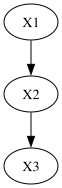

In [2]:
fd0 = StructuralCausalModel({
    "X1": lambda n_samples: np.random.binomial(n=1, p=0.5, size=n_samples),
    "X2": discrete_model(["X1"], {(0,): (0.9,0.1), (1,): (0.2,0.8)}),
    "X3": discrete_model(["X2"], {
        (0): (1, 0.1),
        (1): (0.1, 0.9),
    }),
})

fd0.cgm.draw()

In [3]:
np.random.seed(0)
n_samples = 100_000
ab_test_df = fd0.sample(n_samples=n_samples)
ab_test_df.head()

,X1,X2,X3
0,1,1.0,0.0
1,1,1.0,1.0
2,1,1.0,0.0
3,1,1.0,1.0
4,0,0.0,0.0


True Causal Effect

In [4]:
true_X3_1 = ab_test_df[ab_test_df['X1'] == 1].X3.mean()
true_X3_0 = ab_test_df[ab_test_df['X1'] == 0].X3.mean()
print('X3(1) = {}'.format(true_X3_1))
print('X3(0) = {}'.format(true_X3_0))

true_ATE = true_X3_1 - true_X3_0
print('ATE = {}'.format(true_ATE))

X3(1) = 0.7344679147061768
X3(0) = 0.17141144740785136
ATE = 0.5630564672983254


In [5]:
print(f'Association flow X1 -> X3                      : {np.corrcoef(ab_test_df.X1, ab_test_df.X3)[0, 1]:8.4f}')
print(f'Conditioned association flow X1 -> X3 | X2 = 0 : {np.corrcoef(ab_test_df.X1[ab_test_df['X2'] == 0], ab_test_df.X3[ab_test_df['X2'] == 0])[0, 1]:8.4f}')
print(f'Conditioned association flow X1 -> X3 | X2 = 1 : {np.corrcoef(ab_test_df.X1[ab_test_df['X2'] == 1], ab_test_df.X3[ab_test_df['X2'] == 1])[0, 1]:8.4f}')

Association flow X1 -> X3                      :   0.5656
Conditioned association flow X1 -> X3 | X2 = 0 :  -0.0011
Conditioned association flow X1 -> X3 | X2 = 1 :  -0.0008
